In [ ]:
pip install numpy pandas scikit-learn matplotlib tensorflow gensim datasets transformers


In [ ]:
!pip install scikit-learn

In [ ]:
!pip install sklearn_crfsuite

In [ ]:
# pip uninstall numpy -y

# pip install numpy==1.26.4

In [ ]:
pip install tensorflow==2.11.0

Named Entity Recognition (NER) problem. This will include:

Loading and Preprocessing the Dataset

Train-Validation-Test Split

Data Formatting for Modeling

Baseline Model using CRF (Conditional Random Fields)

Evaluation Metrics

Improved Model using BiLSTM + CRF

Future Scope and System Design Discussion

In [3]:
# 📘 Cell 1: Import Libraries

# "This cell imports necessary libraries for data handling, visualization, modeling, and evaluation. sklearn_crfsuite will be used for the baseline CRF model."

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn_crfsuite import CRF, metrics
import warnings
warnings.filterwarnings("ignore")

from collections import Counter as C
import plotly.express as px
import plotly.io as pio

from sklearn.model_selection import train_test_split
import sklearn_crfsuite
from sklearn_crfsuite import metrics
import pickle

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [2]:
# Load and Explore the Dataset

In [3]:
df = pd.read_csv("ner_dataset.csv", encoding="latin1")
df.head()


,Sentence #,Word,POS,Tag
0,Sentence: 1,Thousands,NNS,O
1,NaN,of,IN,O
2,NaN,demonstrators,NNS,O
3,NaN,have,VBP,O
4,NaN,marched,VBN,O


In [6]:
df.shape

(1048575, 4)

In [1]:
# df["Sentence #"].value_counts()

In [2]:
# C(df["Word"])

In [3]:
# C(df["POS"])

In [4]:
# C(df["Tag"])

In [20]:
df.isna().sum()

Sentence #    1000616
Word               10
POS                 0
Tag                 0
dtype: int64

In [21]:
def get_missing_value_columns(data, threshold=70.0):
    missing_percent = data.isnull().mean() * 100
    high_missing_cols = missing_percent[missing_percent > threshold].index.tolist()
    return high_missing_cols

In [23]:
missing_values_cols= get_missing_value_columns(data=df, threshold=70)

print("Columns with >70% missing values:", missing_values_cols)
len(missing_values_cols)
print("#"*100)
len(missing_values_cols)

Columns with >70% missing values: ['Sentence #']
####################################################################################################


1

In [29]:
def visualize_missing_columns(data, threshold=70.0):
    high_missing = data.isnull().mean() * 100
    # high_missing = missing_percent[missing_percent > threshold].sort_values(ascending=False)
    if high_missing.empty:
        return
    fig = px.bar(high_missing, x=high_missing.index, y=high_missing.values,
                 labels={"x": "Column Name", "y": "% Missing"},
                 title=f"Columns with > {threshold}% Missing Values")
    fig.update_layout(xaxis_tickangle=-45)
    fig.show()


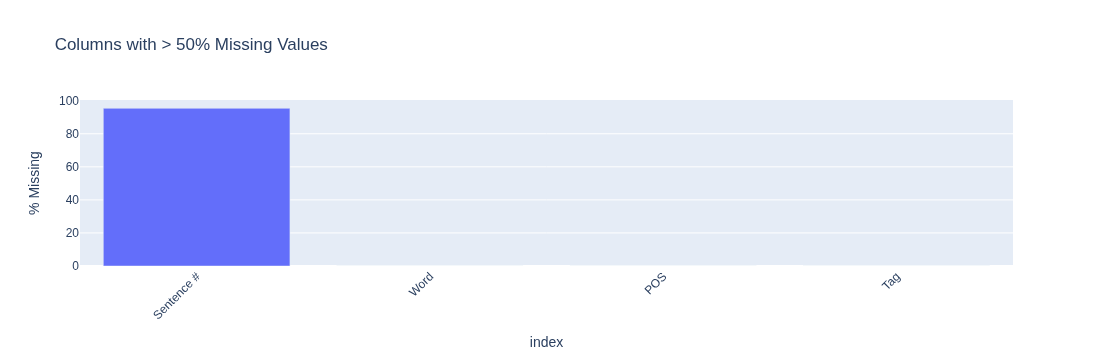

In [30]:
visualize_missing_columns(df, 50)

In [ ]:
# Fill Missing Sentence Numbers

In [31]:
df["Sentence_new"] = df["Sentence #"].fillna(method="ffill")
df.head()


,Sentence #,Word,POS,Tag,Sentence_new
0,Sentence: 1,Thousands,NNS,O,Sentence: 1
1,NaN,of,IN,O,Sentence: 1
2,NaN,demonstrators,NNS,O,Sentence: 1
3,NaN,have,VBP,O,Sentence: 1
4,NaN,marched,VBN,O,Sentence: 1


In [5]:
# C(df["Sentence_new"])

In [34]:
# Group Words and Tags by Sentences : Groups words and corresponding NER tags into complete sentences for processing by sequence models.



In [35]:
agg_func = lambda s: list(s)
grouped = df.groupby("Sentence_new").agg({"Word": agg_func, "Tag": agg_func})
grouped = grouped.reset_index()
grouped.head()


,Sentence_new,Word,Tag
0,Sentence: 1,"[Thousands, of, demonstrators, have, marched, ...","[O, O, O, O, O, O, B-geo, O, O, O, O, O, B-geo..."
1,Sentence: 10,"[Iranian, officials, say, they, expect, to, ge...","[B-gpe, O, O, O, O, O, O, O, O, O, O, O, O, O,..."
2,Sentence: 100,"[Helicopter, gunships, Saturday, pounded, mili...","[O, O, B-tim, O, O, O, O, O, B-geo, O, O, O, O..."
3,Sentence: 1000,"[They, left, after, a, tense, hour-long, stand...","[O, O, O, O, O, O, O, O, O, O, O]"
4,Sentence: 10000,"[U.N., relief, coordinator, Jan, Egeland, said...","[B-geo, O, O, B-per, I-per, O, B-tim, O, B-geo..."


In [37]:
# 📘 Cell 5: Split Dataset into Train, Validation, and Test Sets : Splits the data into training (72%), validation (8%), and testing (20%) sets.


In [38]:
train_val, test = train_test_split(grouped, test_size=0.2, random_state=42)
train, val = train_test_split(train_val, test_size=0.1, random_state=42)

print(f"Train: {len(train)} sentences")
print(f"Validation: {len(val)} sentences")
print(f"Test: {len(test)} sentences")


Train: 34530 sentences
Validation: 3837 sentences
Test: 9592 sentences


In [43]:
# 📘 Step 6: Ensure No NaNs and Convert Words to Strings


In [44]:
def clean_words(data):
    data['Word'] = data['Word'].apply(lambda x: [str(w) if pd.notnull(w) else "" for w in x])
    return data

train = clean_words(train)
val = clean_words(val)
test = clean_words(test)


In [45]:
# Cell 7: Feature Extraction for CRF : Defines functions to extract features per word for CRF modeling and to prepare labels.

In [46]:
def word2features(sent, i):
    word = sent[i]
    features = {
        'bias': 1.0,
        'word.lower()': word.lower(),
        'word[-3:]': word[-3:],
        'word[-2:]': word[-2:],
        'word.isupper()': word.isupper(),
        'word.istitle()': word.istitle(),
        'word.isdigit()': word.isdigit(),
    }
    if i > 0:
        word1 = sent[i-1]
        features.update({
            '-1:word.lower()': word1.lower(),
            '-1:word.istitle()': word1.istitle(),
            '-1:word.isupper()': word1.isupper(),
        })
    else:
        features['BOS'] = True  # Beginning of sentence

    if i < len(sent)-1:
        word1 = sent[i+1]
        features.update({
            '+1:word.lower()': word1.lower(),
            '+1:word.istitle()': word1.istitle(),
            '+1:word.isupper()': word1.isupper(),
        })
    else:
        features['EOS'] = True  # End of sentence
    return features

def extract_features(sentences):
    return [ [word2features(s, i) for i in range(len(s))] for s in sentences]

def get_labels(tags):
    return [tag for tag in tags]


In [47]:
 # Step 8: Prepare Data for CRF Model : Prepare Training Data: Prepares features and labels for all splits.


In [48]:
X_train = extract_features(train['Word'].tolist())
y_train = train['Tag'].tolist()

X_val = extract_features(val['Word'].tolist())
y_val = val['Tag'].tolist()

X_test = extract_features(test['Word'].tolist())
y_test = test['Tag'].tolist()


In [49]:
 # Step 9: Train the CRF Model

In [55]:
crf = sklearn_crfsuite.CRF(
    algorithm='lbfgs',
    c1=0.1,
    c2=0.1,
    max_iterations=100,
    all_possible_transitions=True
)

crf.fit(X_train, y_train)


CRF(algorithm='lbfgs', all_possible_transitions=True, c1=0.1, c2=0.1,
    max_iterations=100)

In [56]:
# 📘 Step 10: Evaluate the CRF Model on Test Data


In [57]:
y_pred = crf.predict(X_test)

print(metrics.flat_classification_report(y_test, y_pred, digits=3))


              precision    recall  f1-score   support

       B-art      0.379     0.117     0.179        94
       B-eve      0.556     0.357     0.435        70
       B-geo      0.859     0.912     0.885      7558
       B-gpe      0.964     0.934     0.948      3142
       B-nat      0.542     0.325     0.406        40
       B-org      0.801     0.722     0.759      4151
       B-per      0.852     0.814     0.832      3400
       B-tim      0.924     0.876     0.900      4077
       I-art      0.286     0.071     0.114        84
       I-eve      0.531     0.262     0.351        65
       I-geo      0.814     0.798     0.806      1462
       I-gpe      0.944     0.515     0.667        33
       I-nat      0.571     0.308     0.400        13
       I-org      0.803     0.804     0.804      3394
       I-per      0.855     0.883     0.868      3406
       I-tim      0.813     0.811     0.812      1251
           O      0.991     0.994     0.992    177590

    accuracy              

In [58]:
 # Step 11: View Sample Predictions

In [59]:
i = 0  # First sentence in test set
words = test.iloc[i]['Word']
true = y_test[i]
pred = y_pred[i]

print("Word\tTrue\tPredicted")
for w, t, p in zip(words, true, pred):
    print(f"{w}\t{t}\t{p}")
 

Word	True	Predicted
The	O	O
report	O	O
calls	O	O
on	O	O
President	B-per	B-per
Bush	I-per	I-per
and	O	O
Congress	B-org	B-org
to	O	O
urge	O	O
Chinese	B-gpe	B-gpe
officials	O	O
not	O	O
to	O	O
use	O	O
the	O	O
global	O	O
war	O	O
against	O	O
terrorism	O	O
as	O	O
a	O	O
pretext	O	O
to	O	O
suppress	O	O
minorities	O	O
'	O	O
rights	O	O
.	O	O


✅ Summary of This Notebook:
Step	Description

✅ Data Cleaning	Removed missing values, grouped by sentences

✅ Train-Test Split	72% train, 8% validation, 20% test

✅ Feature Extraction	Context-based word features

✅ Baseline Model	CRF trained using sklearn_crfsuite

✅ Evaluation	Precision, Recall, F1-score per tag

In [2]:
# BiLSTM + Softmax NER Model with TensorFlow (Jupyter Notebook Style)

# 📦 Import required libraries
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from collections import defaultdict
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical


2025-05-18 01:28:20.993750: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-05-18 01:28:21.592751: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2025-05-18 01:28:21.592785: I tensorflow/compiler/xla/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
2025-05-18 01:28:27.565210: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory
2025-

In [3]:
# 🔍 Step 1: Load and Preprocess Dataset
# Read the CSV dataset, fill missing sentence numbers, and drop POS column


In [4]:

# Explanation:
# - The dataset includes words, their POS tags (ignored), and NER tags.
# - We fill sentence numbers (Sentence #) forward to associate each word.
df1 = pd.read_csv("ner_dataset.csv", encoding="latin1")
df1['Sentence_new']= df1['Sentence #'].fillna(method='ffill')
df1 = df1.drop(columns=['POS'])
df1.head()

,Sentence #,Word,Tag,Sentence_new
0,Sentence: 1,Thousands,O,Sentence: 1
1,NaN,of,O,Sentence: 1
2,NaN,demonstrators,O,Sentence: 1
3,NaN,have,O,Sentence: 1
4,NaN,marched,O,Sentence: 1


In [5]:
# 🧱 Step 2: Group words and tags per sentence
# Explanation:
# - Aggregate words and their corresponding NER tags per sentence.
sentences = df1.groupby("Sentence_new").agg({"Word": list, "Tag": list}).reset_index()
sentences

,Sentence_new,Word,Tag
0,Sentence: 1,"[Thousands, of, demonstrators, have, marched, ...","[O, O, O, O, O, O, B-geo, O, O, O, O, O, B-geo..."
1,Sentence: 10,"[Iranian, officials, say, they, expect, to, ge...","[B-gpe, O, O, O, O, O, O, O, O, O, O, O, O, O,..."
2,Sentence: 100,"[Helicopter, gunships, Saturday, pounded, mili...","[O, O, B-tim, O, O, O, O, O, B-geo, O, O, O, O..."
3,Sentence: 1000,"[They, left, after, a, tense, hour-long, stand...","[O, O, O, O, O, O, O, O, O, O, O]"
4,Sentence: 10000,"[U.N., relief, coordinator, Jan, Egeland, said...","[B-geo, O, O, B-per, I-per, O, B-tim, O, B-geo..."
...,...,...,...
47954,Sentence: 9995,"[Opposition, leader, Mir, Hossein, Mousavi, ha...","[O, O, O, B-per, I-per, O, O, O, O, O, O, O, O..."
47955,Sentence: 9996,"[On, Thursday, ,, Iranian, state, media, publi...","[O, B-tim, O, B-gpe, O, O, O, O, O, O, O, O, B..."
47956,Sentence: 9997,"[Following, Iran, 's, disputed, June, 12, elec...","[O, B-geo, O, O, B-tim, I-tim, O, O, O, O, O, ..."
47957,Sentence: 9998,"[Since, then, ,, authorities, have, held, publ...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ..."


In [6]:
# 🔀 Step 3: Train-Validation-Test Split
# Explanation:
# - Split data into 72% train, 8% validation, 20% test.
train_val, test = train_test_split(sentences, test_size=0.2, random_state=42)
train, val = train_test_split(train_val, test_size=0.1, random_state=42)


In [8]:

# Explanation:
# - Convert unique words and tags to index mappings.
# - Reserve 0 for PAD and 1 for UNK (unknown) words.

# 🧾 Step 4: Create Vocabularies
words = list(set(df1["Word"].values))
tags = list(set(df1["Tag"].values))

word2idx = {w: i + 2 for i, w in enumerate(words)}
word2idx["PAD"] = 0
word2idx["UNK"] = 1
idx2word = {i: w for w, i in word2idx.items()}

# Important fix: Avoid index out-of-bound error in Embedding
vocab_size = max(word2idx.values()) + 1

tag2idx = {t: i for i, t in enumerate(tags)}
tag2idx["PAD"] = len(tag2idx)
idx2tag = {i: t for t, i in tag2idx.items()}

In [9]:
# 🔠 Step 5: Encode and Pad Sentences
# Explanation:
# - Convert words and tags to indices.
# - Pad sequences to a fixed MAX_LEN.
# - Convert tags to one-hot encoding.
def encode_and_pad(data, word2idx, tag2idx, max_len):
    X, y = [], []
    for _, row in data.iterrows():
        word_seq = [word2idx.get(w, word2idx["UNK"]) for w in row['Word']]
        tag_seq = [tag2idx[t] for t in row['Tag']]
        X.append(word_seq)
        y.append(tag_seq)
    X = pad_sequences(X, maxlen=max_len, value=word2idx['PAD'], padding='post')
    y = pad_sequences(y, maxlen=max_len, value=tag2idx['PAD'], padding='post')
    y = [to_categorical(i, num_classes=len(tag2idx)) for i in y]
    return np.array(X), np.array(y)


In [10]:

MAX_LEN = 75
X_train, y_train = encode_and_pad(train, word2idx, tag2idx, MAX_LEN)
X_val, y_val = encode_and_pad(val, word2idx, tag2idx, MAX_LEN)
X_test, y_test = encode_and_pad(test, word2idx, tag2idx, MAX_LEN)

In [11]:
# 💾 Step 6: Save Vocab Mappings
# Explanation:
# - Save word2idx, tag2idx, and their reverse mappings to use later in inference.

with open("ner_vocab_tf.pkl", "wb") as f:
    pickle.dump((word2idx, tag2idx, idx2word, idx2tag), f)


In [12]:
# ✅ Output the shape of encoded training data
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (34530, 75)
y_train shape: (34530, 75, 18)


In [13]:
# 🧠 Step 7: Define BiLSTM + CRF Model
# Explanation:
# - Embedding layer turns word indices into vectors.
# - BiLSTM captures context from both directions.
# - CRF handles structured prediction across tags.

input = tf.keras.layers.Input(shape=(MAX_LEN,))
model = tf.keras.layers.Embedding(input_dim=vocab_size, output_dim=64, input_length=MAX_LEN, mask_zero=True)(input)
model = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(units=64, return_sequences=True))(model)

2025-05-18 01:29:25.003111: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory
2025-05-18 01:29:25.003146: W tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:265] failed call to cuInit: UNKNOWN ERROR (303)
2025-05-18 01:29:25.003171: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (a-Vostro-15-3568): /proc/driver/nvidia/version does not exist
2025-05-18 01:29:25.003459: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [14]:

output = tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(len(tag2idx), activation='softmax'))(model)

In [15]:
model = tf.keras.Model(input, output)

In [16]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [17]:
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 75)]              0         
                                                                 
 embedding (Embedding)       (None, 75, 64)            2251520   
                                                                 
 bidirectional (Bidirectiona  (None, 75, 128)          66048     
 l)                                                              
                                                                 
 time_distributed (TimeDistr  (None, 75, 18)           2322      
 ibuted)                                                         
                                                                 
Total params: 2,319,890
Trainable params: 2,319,890
Non-trainable params: 0
_________________________________________________________________


In [18]:
# 🏋️ Step 8: Train the Model
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=32,
    epochs=3,
    verbose=1
)


Epoch 1/3
1080/1080 [==============================] - 105s 91ms/step - loss: 0.3617 - accuracy: 0.9134 - val_loss: 0.1384 - val_accuracy: 0.9599
Epoch 2/3
1080/1080 [==============================] - 107s 99ms/step - loss: 0.1043 - accuracy: 0.9690 - val_loss: 0.1152 - val_accuracy: 0.9661
Epoch 3/3
1080/1080 [==============================] - 87s 81ms/step - loss: 0.0760 - accuracy: 0.9766 - val_loss: 0.1120 - val_accuracy: 0.9667


In [19]:
# 📊 Step 9: Evaluate and Predict
model.evaluate(X_test, y_test)

300/300 [==============================] - 5s 16ms/step - loss: 0.1074 - accuracy: 0.9679


[0.10741680860519409, 0.9679454565048218]

In [20]:
# Generate flattened true/predicted tag lists for classification report
# y_true_flat = []
# y_pred_flat = []

# for i in range(len(X_test)):
#     pred = model.predict(X_test[i:i+1])
#     pred_idx = np.argmax(pred[0], axis=-1)
#     true_idx = np.argmax(y_test[i], axis=-1)
#     for t, p in zip(true_idx, pred_idx):
#         if t != tag2idx["PAD"]:
#             y_true_flat.append(idx2tag[t])
#             y_pred_flat.append(idx2tag[p])

# print("\nClassification Report:")
# print(classification_report(y_true_flat, y_pred_flat))

In [21]:
# 🔍 View prediction example
i = 0
x_sample = X_test[i:i+1]
y_true = np.argmax(y_test[i], axis=-1)
y_pred = model.predict(x_sample)
y_pred = np.argmax(y_pred[0], axis=-1)

print("\nWord\tTrue\tPred")
for w, t, p in zip(X_test[i], y_true, y_pred):
    if w != word2idx['PAD']:
        print(f"{idx2word[w]}\t{idx2tag[t]}\t{idx2tag[p]}")


1/1 [==============================] - 2s 2s/step

Word	True	Pred
The	O	O
report	O	O
calls	O	O
on	O	O
President	B-per	B-per
Bush	I-per	I-per
and	O	O
Congress	B-org	B-org
to	O	O
urge	O	O
Chinese	B-gpe	B-gpe
officials	O	O
not	O	O
to	O	O
use	O	O
the	O	O
global	O	O
war	O	O
against	O	O
terrorism	O	O
as	O	O
a	O	O
pretext	O	O
to	O	O
suppress	O	O
minorities	O	O
'	O	O
rights	O	O
.	O	O
